## Meto Data analysis
                "    \"ERA5\": {",
                "        \"pr_ds\": load_precip,",
                "        \"tas_ds\": load_temp,",
                "        \"color\": \"black\",",
                "        \"linestyle\": \"-\",",
                "        \"linewidth\": 1.3,",
                "    },",
                "    \"CMIP historical\": {",
                "        \"pr_ds\": load_cmip_pr,",
                "        \"tas_ds\": load_cmip_tas,",
                "        \"color\": \"tab:orange\",",
                "        \"linestyle\": \"-\",",
                "        \"linewidth\": 1.3,",
                "    },",
                "    \"CMIP SSP126\": {",
                "        \"pr_ds\": load_cmip_future_pr_ssp126,",
                "        \"tas_ds\": load_cmip_future_tas_ssp126,",
                "        \"color\": \"tab:purple\",",
                "        \"linestyle\": \"--\",",
                "        \"linewidth\": 1.2,",
                "    },",
                "    \"CMIP SSP245\": {",
                "        \"pr_ds\": load_cmip_future_pr,",
                "        \"tas_ds\": load_cmip_future_tas,",
                "        \"color\": \"tab:green\",",
                "        \"linestyle\": \"--\",",
                "        \"linewidth\": 1.2,",
                "    },",
                "    \"CMIP SSP585\": {",
                "        \"pr_ds\": load_cmip_future_pr_ssp585,",
                "        \"tas_ds\": load_cmip_future_tas_ssp585,",
                "        \"color\": \"tab:brown\",",
                "        \"linestyle\": \"--\",",
                "        \"linewidth\": 1.2,",
                "    },",
                "    \"CMIP SSP126 Original\": {",
                "        \"pr_ds\": load_cmip_future_pr_ssp126_original,",
                "        \"tas_ds\": load_cmip_future_tas_ssp126_original,",
                "        \"color\": \"tab:purple\",",
                "        \"linestyle\": \"-.\",",
                "        \"linewidth\": 1.2,",
                "    },",
                "    \"CMIP SSP245 Original\": {",
                "        \"pr_ds\": load_cmip_future_pr_original,",
                "        \"tas_ds\": load_cmip_future_tas_original,",
                "        \"color\": \"tab:green\",",
                "        \"linestyle\": \"-.\",",
                "        \"linewidth\": 1.2,",
                "    },",
                "    \"CMIP SSP585 Original\": {",
                "        \"pr_ds\": load_cmip_future_pr_ssp585_original,",
                "        \"tas_ds\": load_cmip_future_tas_ssp585_original,",
                "        \"color\": \"tab:brown\",",
                "        \"linestyle\": \"-.\",",
                "        \"linewidth\": 1.2,",
load_cmip_future_pr_ssp126 = xr.open_dataset(cmip_future_pr_path_ssp126, chunks=chunks)
load_cmip_future_tas_ssp126 = xr.open_dataset(cmip_future_tas_path_ssp126, chunks=chunks)

load_cmip_future_pr_ssp585 = xr.open_dataset(cmip_future_pr_path_ssp585, chunks=chunks)
load_cmip_future_tas_ssp585 = xr.open_dataset(cmip_future_tas_path_ssp585, chunks=chunks)

load_cmip_future_pr_original = xr.open_dataset(cmip_future_pr_path_original, chunks=chunks)
load_cmip_future_tas_original = xr.open_dataset(cmip_future_tas_path_original, chunks=chunks)

load_cmip_future_pr_ssp126_original = xr.open_dataset(cmip_future_pr_path_ssp126_original, chunks=chunks)
load_cmip_future_tas_ssp126_original = xr.open_dataset(cmip_future_tas_path_ssp126_original, chunks=chunks)

load_cmip_future_pr_ssp585_original = xr.open_dataset(cmip_future_pr_path_ssp585_original, chunks=chunks)
load_cmip_future_tas_ssp585_original = xr.open_dataset(cmip_future_tas_path_ssp585_original, chunks=chunks)



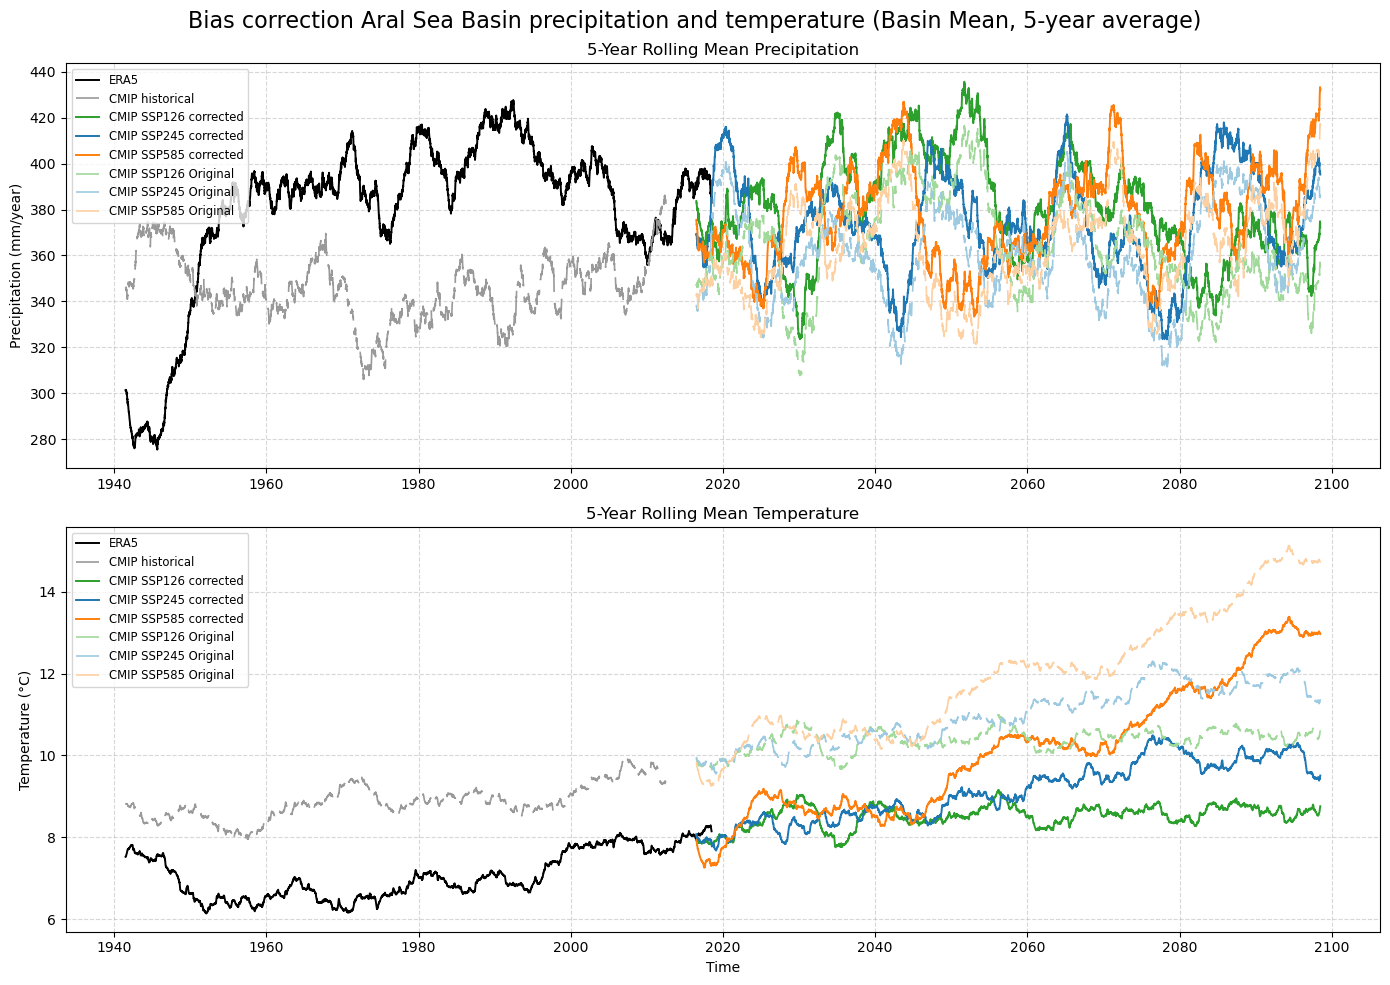

In [25]:
import matplotlib.pyplot as plt

def pick_var(ds, preferred):
    return preferred if preferred in ds.data_vars else list(ds.data_vars)[0]

def basin_daily_series(ds, var_name):
    da = ds[var_name]
    spatial_dims = [d for d in da.dims if d != "time"]
    if spatial_dims:
        da = da.mean(dim=spatial_dims)
    return da

experiments = {
    "ERA5": {
        "pr_ds": load_precip,
        "tas_ds": load_temp,
        "color": "black",
        "linestyle": "-",
        "linewidth": 1.4,
    },
    "CMIP historical": {
        "pr_ds": load_cmip_pr,
        "tas_ds": load_cmip_tas,
        "color": "0.6",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    },
    "CMIP SSP126 corrected": {
        "pr_ds": load_cmip_future_pr_ssp126,
        "tas_ds": load_cmip_future_tas_ssp126,
        "color": "tab:green",
        "linestyle": "-",
        "linewidth": 1.4,
    },
    "CMIP SSP245 corrected": {
        "pr_ds": load_cmip_future_pr,
        "tas_ds": load_cmip_future_tas,
        "color": "tab:blue",
        "linestyle": "-",
        "linewidth": 1.4,
    },
    "CMIP SSP585 corrected": {
        "pr_ds": load_cmip_future_pr_ssp585,
        "tas_ds": load_cmip_future_tas_ssp585,
        "color": "tab:orange",
        "linestyle": "-",
        "linewidth": 1.4,
    },
    "CMIP SSP126 Original": {
        "pr_ds": load_cmip_future_pr_ssp126_original,
        "tas_ds": load_cmip_future_tas_ssp126_original,
        "color": "#a1d99b",
        #"linestyle": "-.",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    },
    "CMIP SSP245 Original": {
        "pr_ds": load_cmip_future_pr_original,
        "tas_ds": load_cmip_future_tas_original,
        "color": "#9ecae1",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    },
    "CMIP SSP585 Original": {
        "pr_ds": load_cmip_future_pr_ssp585_original,
        "tas_ds": load_cmip_future_tas_ssp585_original,
        "color": "#fdd0a2",
        "linestyle" : (0, (16,8)),
        "linewidth": 1.2,
    }

}

# Build basin-mean daily series with unit conversions.
pr_daily_mm = {}
tas_daily_c = {}
for name, cfg in experiments.items():
    pr_var = pick_var(cfg["pr_ds"], "pr")
    tas_var = pick_var(cfg["tas_ds"], "tas")
    pr_daily_mm[name] = basin_daily_series(cfg["pr_ds"], pr_var) * 1000.0
    tas_daily_c[name] = basin_daily_series(cfg["tas_ds"], tas_var) - 273.15

# Rolling statistics:
# - precipitation: rolling mean daily precipitation, then scaled to mm/year
# - temperature: rolling mean in C
window_years = 5
window_days = window_years * 365

# For large rolling windows, rechunking time can reduce dask overhead.
roll_chunk_days = max(window_days * 2, 365)
for name in experiments:
    pr_daily_mm[name] = pr_daily_mm[name].chunk({"time": roll_chunk_days})
    tas_daily_c[name] = tas_daily_c[name].chunk({"time": roll_chunk_days})

pr_roll_mm_per_year = {
    name: da.rolling(time=window_days, center=True).mean() * 365.0
    for name, da in pr_daily_mm.items()
}
tas_roll_c = {
    name: da.rolling(time=window_days, center=True).mean()
    for name, da in tas_daily_c.items()
}

# Keep legacy variable names available for downstream cells.
era5_pr_roll_mm_per_year = pr_roll_mm_per_year["ERA5"]
cmip_pr_roll_mm_per_year = pr_roll_mm_per_year["CMIP historical"]
cmip_future_pr_roll_mm_per_year_ssp126 = pr_roll_mm_per_year["CMIP SSP126 corrected"]
cmip_future_pr_roll_mm_per_year = pr_roll_mm_per_year["CMIP SSP245 corrected"]
cmip_future_pr_roll_mm_per_year_ssp585 = pr_roll_mm_per_year["CMIP SSP585 corrected"]

era5_tas_roll_c = tas_roll_c["ERA5"]
cmip_tas_roll_c = tas_roll_c["CMIP historical"]
cmip_future_tas_roll_c_ssp126 = tas_roll_c["CMIP SSP126 corrected"]
cmip_future_tas_roll_c = tas_roll_c["CMIP SSP245 corrected"]
cmip_future_tas_roll_c_ssp585 = tas_roll_c["CMIP SSP585 corrected"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for name, cfg in experiments.items():
    pr_series = pr_roll_mm_per_year[name].compute()
    ax1.plot(
        pr_series["time"],
        pr_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=f"{name}", # {window_years}-year rolling precip (mm/year)",
    )

ax1.set_ylabel("Precipitation (mm/year)")
ax1.set_title(f"{window_years}-Year Rolling Mean Precipitation")
ax1.legend(loc="upper left", fontsize="small")
ax1.grid(linestyle='--', alpha=0.5)

for name, cfg in experiments.items():
    tas_series = tas_roll_c[name].compute()
    ax2.plot(
        tas_series["time"],
        tas_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=f"{name}", # {window_years}-year rolling temperature (C)",
    )

ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title(f"{window_years}-Year Rolling Mean Temperature")
ax2.legend(loc="upper left", fontsize="small")
ax2.grid(linestyle='--', alpha=0.5)

suptitle = f"Bias correction Aral Sea Basin precipitation and temperature (Basin Mean, {window_years}-year average)"

fig.suptitle(suptitle, fontsize=16)
plt.tight_layout()
plt.show()

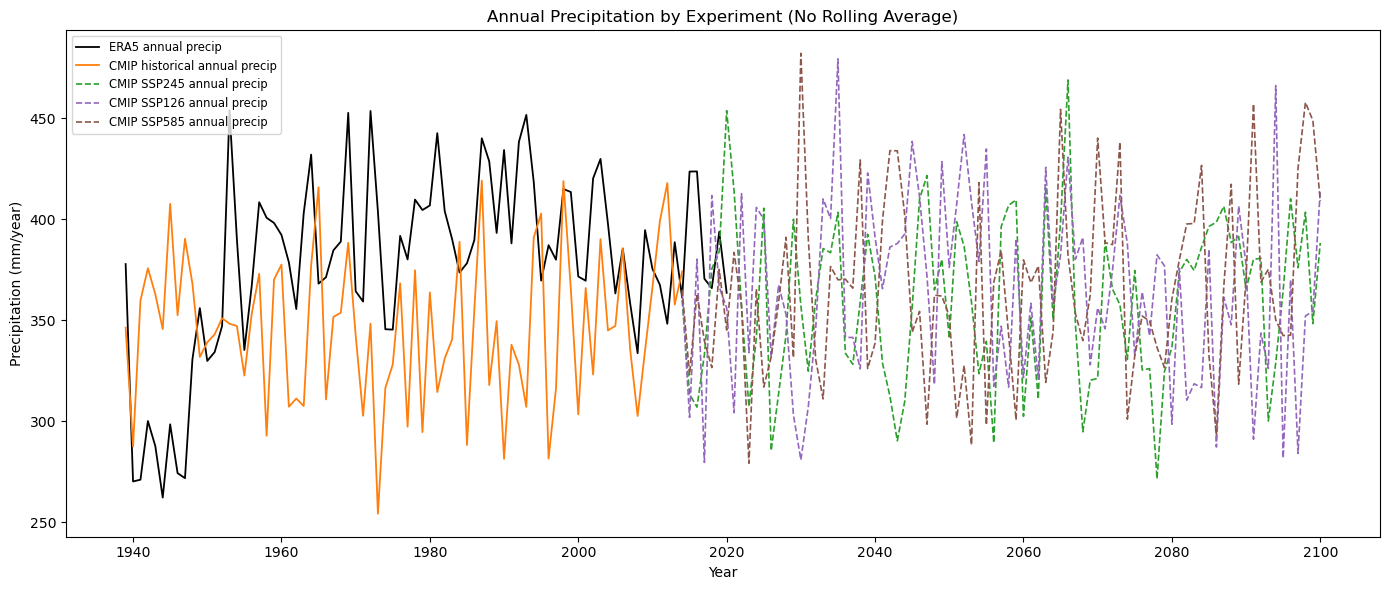

First 3 annual precipitation values (mm/year) per experiment:

ERA5:
time
1939-12-31    377.791260
1940-12-31    270.250336
1941-12-31    271.132507
Freq: YE-DEC, Name: pr, dtype: float32

CMIP historical:
time
1939-12-31    346.325989
1940-12-31    287.612183
1941-12-31    359.799500
Freq: YE-DEC, Name: pr, dtype: float32

CMIP SSP245:
time
2014-12-31    359.990326
2015-12-31    313.419861
2016-12-31    307.036469
Freq: YE-DEC, Name: pr, dtype: float32

CMIP SSP126:
time
2014-12-31    363.901245
2015-12-31    301.927734
2016-12-31    380.277191
Freq: YE-DEC, Name: pr, dtype: float32

CMIP SSP585:
time
2014-12-31    365.134064
2015-12-31    323.012512
2016-12-31    363.080078
Freq: YE-DEC, Name: pr, dtype: float32


In [21]:
import matplotlib.pyplot as plt

# Reuse daily basin-mean precipitation from the previous cell (already chunk-aware).
annual_pr_mm = {
    name: da.resample(time="YE").sum()
    for name, da in pr_daily_mm.items()
}

plt.figure(figsize=(14, 6))
plot_order = ["ERA5", "CMIP historical", "CMIP SSP245", "CMIP SSP126", "CMIP SSP585"]

for name in plot_order:
    cfg = experiments[name]
    series = annual_pr_mm[name].compute()
    plt.plot(
        series["time"].dt.year,
        series,
        label=f"{name} annual precip",
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        linewidth=cfg["linewidth"],
    )

plt.xlabel("Year")
plt.ylabel("Precipitation (mm/year)")
plt.title("Annual Precipitation by Experiment (No Rolling Average)")
plt.legend(loc="best", fontsize="small")
plt.tight_layout()
plt.show()

print("First 3 annual precipitation values (mm/year) per experiment:")
for name in plot_order:
    head3 = annual_pr_mm[name].isel(time=slice(0, 3)).compute()
    print(f"\n{name}:")
    print(head3.to_series())

In [22]:
# Use the same variable-picking logic as above and check both space + time compatibility.
tas_obs_name = "tas" if "tas" in load_temp.data_vars else list(load_temp.data_vars)[0]
tas_hist_name = "tas" if "tas" in load_cmip_tas.data_vars else list(load_cmip_tas.data_vars)[0]

obs_tas_raw = load_temp[tas_obs_name]
simh_tas = load_cmip_tas[tas_hist_name]

print(f"Raw time lengths -> obs: {obs_tas_raw.sizes['time']}, simh: {simh_tas.sizes['time']}")
print(f"Raw spatial sizes -> obs(lat,lon): ({obs_tas_raw.sizes['lat']}, {obs_tas_raw.sizes['lon']}), simh(lat,lon): ({simh_tas.sizes['lat']}, {simh_tas.sizes['lon']})")

# Match obs grid to historical CMIP grid so cmethods sees identical non-time coordinates.
obs_tas_on_simh_grid = obs_tas_raw.interp(lat=simh_tas["lat"], lon=simh_tas["lon"], method="linear")
obs_tas_aligned, simh_tas_aligned = xr.align(obs_tas_on_simh_grid, simh_tas, join="inner")

print(f"Aligned time lengths -> obs: {obs_tas_aligned.sizes['time']}, simh: {simh_tas_aligned.sizes['time']}")
print(f"Aligned spatial sizes -> obs(lat,lon): ({obs_tas_aligned.sizes['lat']}, {obs_tas_aligned.sizes['lon']}), simh(lat,lon): ({simh_tas_aligned.sizes['lat']}, {simh_tas_aligned.sizes['lon']})")

Raw time lengths -> obs: 29951, simh: 27759
Raw spatial sizes -> obs(lat,lon): (89, 113), simh(lat,lon): (89, 113)
Aligned time lengths -> obs: 27759, simh: 27759
Aligned spatial sizes -> obs(lat,lon): (89, 113), simh(lat,lon): (89, 113)


In [23]:
from cmethods import adjust

In [26]:
# Prepare obs/simh/simp on the same grid and overlapping timestamps for QDM.
tas_obs_name = "tas" if "tas" in load_temp.data_vars else list(load_temp.data_vars)[0]
tas_hist_name = "tas" if "tas" in load_cmip_tas.data_vars else list(load_cmip_tas.data_vars)[0]
tas_future_name = "tas" if "tas" in load_cmip_future_tas.data_vars else list(load_cmip_future_tas.data_vars)[0]

obs_tas_raw = load_temp[tas_obs_name]
simh_tas = load_cmip_tas[tas_hist_name]
simp_tas = load_cmip_future_tas[tas_future_name]

# Interpolate obs to historical CMIP grid (required for cmethods spatial alignment).
obs_tas_on_simh_grid = obs_tas_raw.interp(lat=simh_tas["lat"], lon=simh_tas["lon"], method="linear")

# Historical pair must share the same time axis for fitting.
obs_tas_aligned, simh_tas_aligned = xr.align(obs_tas_on_simh_grid, simh_tas, join="inner")

# Future simulation should use the same spatial coordinates as simh.
simp_tas_on_simh_grid = simp_tas.interp(lat=simh_tas["lat"], lon=simh_tas["lon"], method="linear")

print(f"Aligned obs/simh time lengths -> obs: {obs_tas_aligned.sizes['time']}, simh: {simh_tas_aligned.sizes['time']}")
assert obs_tas_aligned.sizes["time"] == simh_tas_aligned.sizes["time"], "obs and simh still have different lengths"

# cmethods uses apply_ufunc with time as a core dimension, so time must be a single chunk.
# Keep spatial chunking to avoid very large in-memory arrays per task.
qdm_chunks = {"time": -1}
if "lat" in simh_tas_aligned.dims:
    qdm_chunks["lat"] = 16
if "lon" in simh_tas_aligned.dims:
    qdm_chunks["lon"] = 16

obs_qdm = obs_tas_aligned.chunk(qdm_chunks)
simh_qdm = simh_tas_aligned.chunk(qdm_chunks)
simp_qdm = simp_tas_on_simh_grid.chunk(qdm_chunks)

qdm_result = adjust(
    method="quantile_delta_mapping",
    obs=obs_qdm,
    simh=simh_qdm,
    simp=simp_qdm,
    n_quantiles=1000,
    kind="+",
)

Aligned obs/simh time lengths -> obs: 27759, simh: 27759


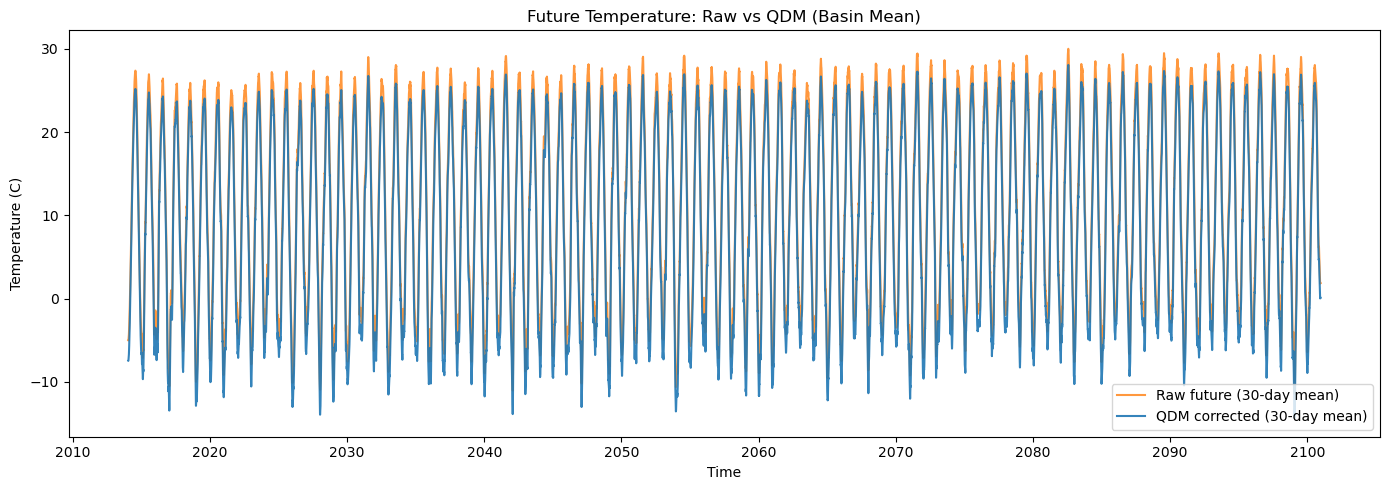

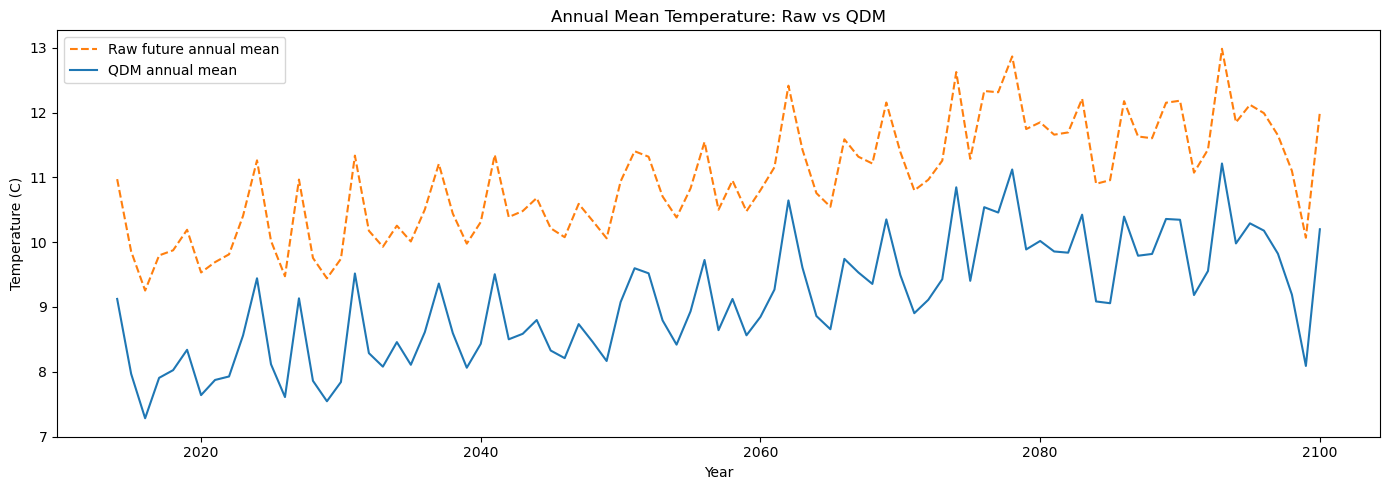

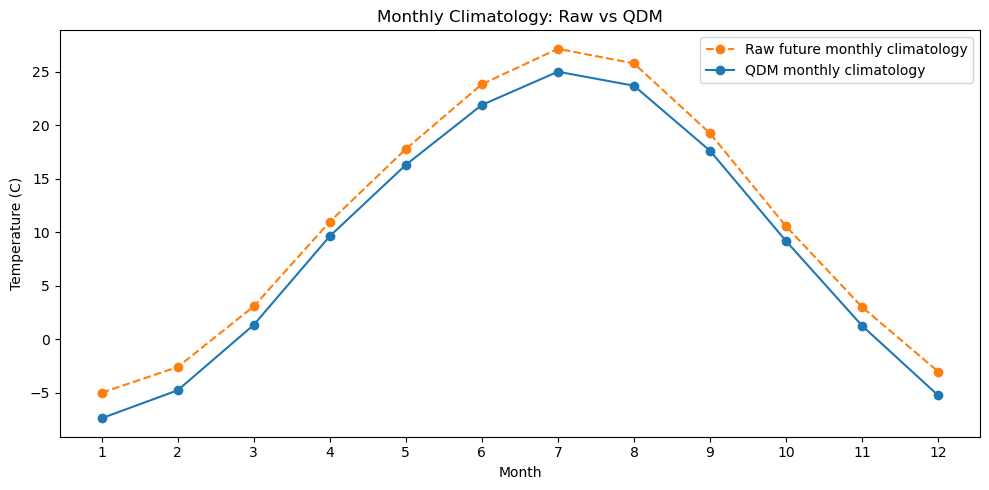

In [32]:
import matplotlib.pyplot as plt

# qdm_result is returned as a Dataset; pick its main variable.
qdm_var = list(qdm_result.data_vars)[0]
qdm_tas = qdm_result[qdm_var]
raw_future_tas = simp_tas_on_simh_grid

def basin_mean(da):
    dims = [d for d in da.dims if d != "time"]
    return da.mean(dim=dims) if dims else da

qdm_basin = basin_mean(qdm_tas)
raw_basin = basin_mean(raw_future_tas)

# Convert to Celsius when data appears to be in Kelvin.
if float(qdm_basin.mean().compute()) > 150:
    qdm_basin = qdm_basin - 273.15
if float(raw_basin.mean().compute()) > 150:
    raw_basin = raw_basin - 273.15

# 1) Daily time series (lightly smoothed)
qdm_roll = qdm_basin.rolling(time=30, center=True).mean().compute()
raw_roll = raw_basin.rolling(time=30, center=True).mean().compute()

plt.figure(figsize=(14, 5))
plt.plot(raw_roll["time"], raw_roll, label="Raw future (30-day mean)", color="tab:orange", alpha=0.8)
plt.plot(qdm_roll["time"], qdm_roll, label="QDM corrected (30-day mean)", color="tab:blue", alpha=0.9)
plt.title("Future Temperature: Raw vs QDM (Basin Mean)")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Annual mean comparison
raw_annual = raw_basin.resample(time="YE").mean().compute()
qdm_annual = qdm_basin.resample(time="YE").mean().compute()

plt.figure(figsize=(14, 5))
plt.plot(raw_annual["time"].dt.year, raw_annual, label="Raw future annual mean", color="tab:orange", linestyle="--")
plt.plot(qdm_annual["time"].dt.year, qdm_annual, label="QDM annual mean", color="tab:blue")
plt.title("Annual Mean Temperature: Raw vs QDM")
plt.xlabel("Year")
plt.ylabel("Temperature (C)")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Monthly climatology (future period)
raw_monthly = raw_basin.groupby("time.month").mean().compute()
qdm_monthly = qdm_basin.groupby("time.month").mean().compute()

plt.figure(figsize=(10, 5))
plt.plot(raw_monthly["month"], raw_monthly, "o--", label="Raw future monthly climatology", color="tab:orange")
plt.plot(qdm_monthly["month"], qdm_monthly, "o-", label="QDM monthly climatology", color="tab:blue")
plt.xticks(range(1, 13))
plt.title("Monthly Climatology: Raw vs QDM")
plt.xlabel("Month")
plt.ylabel("Temperature (C)")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:

resampled_era5_tas = era5_tas_roll_c.resample(time="YE").mean()

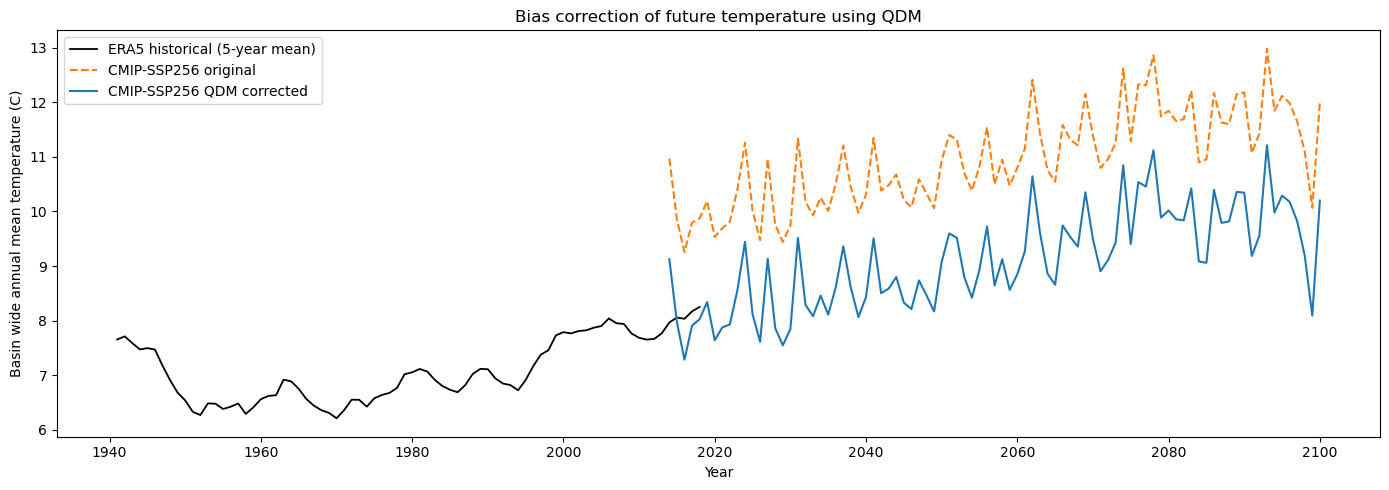

In [46]:


plt.figure(figsize=(14, 5))
plt.plot(resampled_era5_tas["time"].dt.year, resampled_era5_tas, label="ERA5 historical (5-year mean)", color="black", linewidth=1.3)
plt.plot(raw_annual["time"].dt.year, raw_annual, label="CMIP-SSP256 original", color="tab:orange", linestyle="--")
plt.plot(qdm_annual["time"].dt.year, qdm_annual, label="CMIP-SSP256 QDM corrected", color="tab:blue")
plt.title("Bias correction of future temperature using QDM")
plt.xlabel("Year")
plt.ylabel("Basin wide annual mean temperature (C)")
plt.legend()
plt.tight_layout()
plt.show()
